# Basic Agent

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

groq_key = os.getenv("GROQ_API_KEY").strip()
print(os.getenv("GROQ_API_KEY")[:10])

gsk_rqV2sF


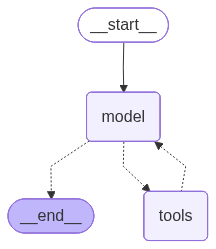

In [2]:
from langchain_groq import ChatGroq
from langchain.agents import create_agent

def weather (city:str)->str:
    """Get the weather of city"""                  # Docstring is needed , else error will arise
    return f"The weather in {city} is sunny."

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY").strip()
)

agent = create_agent(
    model=llm,
    tools=[weather],
    system_prompt="You are a helpful assistant"
)

agent

In [3]:
response = agent.invoke({"messages":[{"role":"user" , "content":"what is the weather of new york city ?"}]})

In [4]:
response["messages"]

[HumanMessage(content='what is the weather of new york city ?', additional_kwargs={}, response_metadata={}, id='0f4504d0-977d-477c-92ba-84ea4e00d487'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ztgcq12h9', 'function': {'arguments': '{"city":"new york city"}', 'name': 'weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 222, 'total_tokens': 238, 'completion_time': 0.056767453, 'completion_tokens_details': None, 'prompt_time': 0.016685973, 'prompt_tokens_details': None, 'queue_time': 0.071093047, 'total_time': 0.073453426}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e86d3-41e7-74f0-8016-1fe1a396220c-0', tool_calls=[{'name': 'weather', 'args': {'city': 'new york city'}, 'id': 'ztgcq12h9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inp

In [61]:
agent.invoke({"messages":"what is the weather of india"})

{'messages': [HumanMessage(content='what is the weather of india', additional_kwargs={}, response_metadata={}, id='66882cef-4d22-45a6-b94e-9e4a9cabdabd'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5e7rqwjn7', 'function': {'arguments': '{"city":"India"}', 'name': 'weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 219, 'total_tokens': 233, 'completion_time': 0.065684491, 'completion_tokens_details': None, 'prompt_time': 0.02359652, 'prompt_tokens_details': None, 'queue_time': 0.180425049, 'total_time': 0.089281011}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e824f-0682-79a1-970f-de24c51d1b0d-0', tool_calls=[{'name': 'weather', 'args': {'city': 'India'}, 'id': '5e7rqwjn7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

# Models Integration with LLM

## Gemini model

In [6]:
from dotenv import load_dotenv
import os
load_dotenv()


os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

In [10]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
        "google_genai:gemini-2.5-flash-lite"       # Give no spaces here
        )

response = model.invoke("Why do parratos talk ?")
print(response.content)

The word "parratos" is not a commonly recognized term in the English language. It's possible it's a misspelling or a term from a specific dialect or context. To give you the most accurate answer, could you please clarify what "parratos" refers to?

However, if you're asking about **parrots** (which sounds very similar and is a common word), here's why they talk:

Parrots are renowned for their ability to mimic sounds, including human speech. This remarkable ability stems from a combination of factors:

*   **Vocal Anatomy:** Parrots possess a specialized vocal organ called the **syrinx**. This organ is located at the base of their trachea (windpipe) and is much more complex than the larynx found in mammals. The syrinx allows parrots to produce a wide range of sounds and control their pitch and tone with great precision.
*   **Brain Structure and Intelligence:** Parrots are highly intelligent birds. They have a relatively large brain-to-body size ratio and exhibit advanced cognitive abi

## Groq model


In [13]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("How are you ?")
print(response.content)

<think>
Let me think carefully about this greeting. The user is asking "How are you?" which is a very common open-ended question. I need to consider how best to respond in a way that's authentic while also being helpful.

First, I should acknowledge the greeting in a friendly manner. I want to be sincere about my capabilities - I can process information and generate responses, but I don't experience feelings in the way humans do. It's important to be clear about this distinction.

At the same time, I want to keep the conversation moving forward. Rather than getting stuck on the technicalities of my nature, I should focus on how I can be useful to the user. I can let them know I'm ready to help with whatever they need, whether it's finding information, solving problems, or just having an interesting discussion.

I should also consider the emotional aspect of this question. When people ask "How are you?" they're often showing interest in others. I can respond in a way that acknowledges t